In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("global_cancer_patients_2015_2024.csv")

In [3]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [5]:
data.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isnull().sum()

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

#Descriptive Analysis

In [8]:
data["Age"]

0        71
1        34
2        80
3        40
4        43
         ..
49995    80
49996    40
49997    74
49998    21
49999    22
Name: Age, Length: 50000, dtype: int64

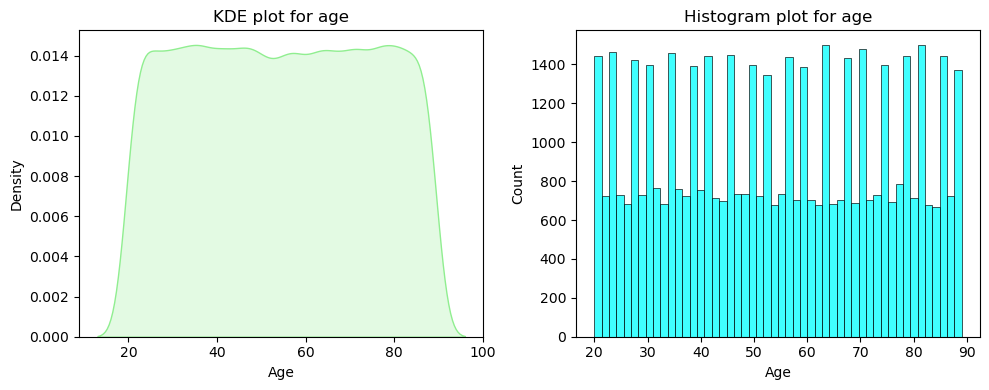

In [9]:
#Age column
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Age"],fill=True,color="lightgreen")
plt.title("KDE plot for age")

plt.subplot(1,2,2)
sns.histplot(data["Age"],bins=50,kde=False,color="cyan")
plt.title("Histogram plot for age")

plt.tight_layout()
plt.show()

In [10]:
data["Age"].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

In [11]:
#Gender column
data["Gender"].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

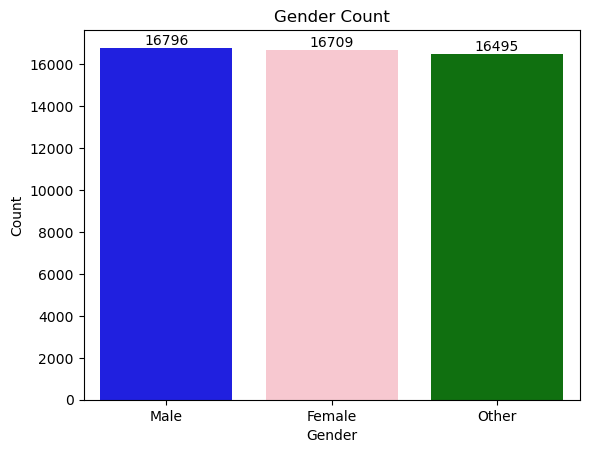

In [12]:
sns.barplot(
    x=data["Gender"].value_counts().index,
    y=data["Gender"].value_counts().values,
    palette=["blue","pink","green"]
)

for i ,v in enumerate(data["Gender"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="bottom")

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [13]:
#Countries column
country_count=data["Country_Region"].value_counts()

In [14]:
country_count

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

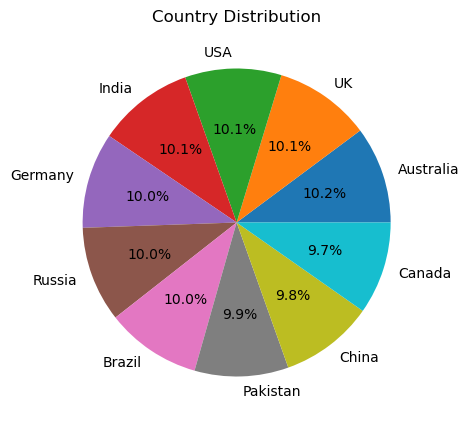

In [15]:
plt.figure(figsize=(5,5))
plt.pie(x=country_count.values,
        labels=country_count.index,
        autopct="%1.1f%%"
)
plt.title("Country Distribution")
plt.show()

In [16]:
#Cancer column
data["Cancer_Type"].value_counts()

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

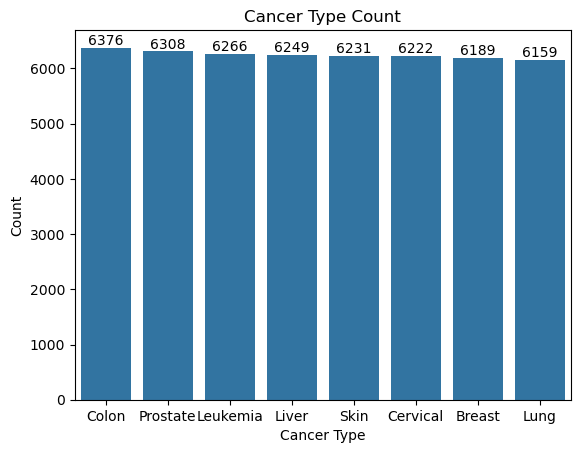

In [17]:
sns.barplot(x=data["Cancer_Type"].value_counts().index,
            y=data["Cancer_Type"].value_counts().values,
           )

for i,v in enumerate(data["Cancer_Type"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="bottom")

plt.title("Cancer Type Count")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

In [18]:
# Cancer Stage
data["Cancer_Stage"].value_counts()

Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64

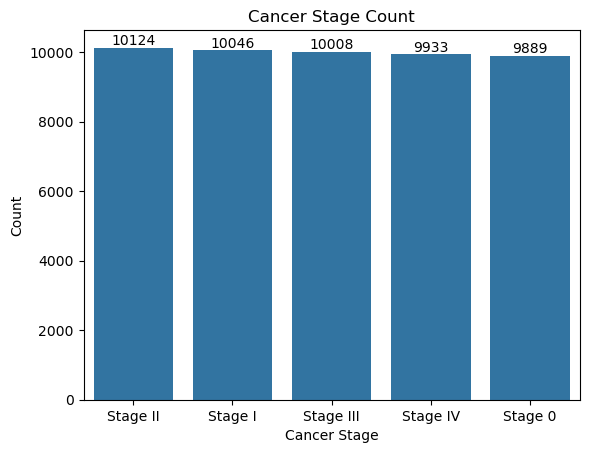

In [19]:
sns.barplot(x=data["Cancer_Stage"].value_counts().index,
            y=data["Cancer_Stage"].value_counts().values,
           )

for i,v in enumerate(data["Cancer_Stage"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="bottom")

plt.title("Cancer Stage Count")
plt.xlabel("Cancer Stage")
plt.ylabel("Count")
plt.show()

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [21]:
#Cancer Treatment Cost
data["Treatment_Cost_USD"]

0        62913.44
1        12573.41
2         6984.33
3        67446.25
4        77977.12
           ...   
49995    71463.70
49996    49619.66
49997     5338.25
49998    45100.47
49999    64023.82
Name: Treatment_Cost_USD, Length: 50000, dtype: float64

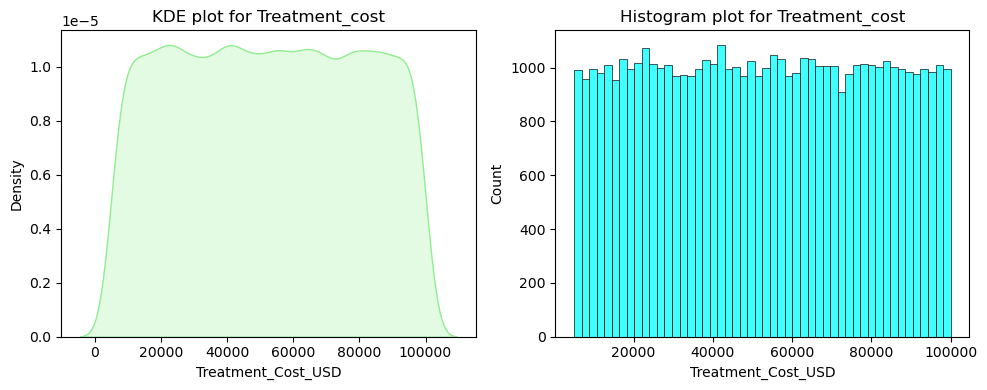

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"],fill=True,color="lightgreen")
plt.title("KDE plot for Treatment_cost")

plt.subplot(1,2,2)
sns.histplot(data["Treatment_Cost_USD"],bins=50,kde=False,color="cyan")
plt.title("Histogram plot for Treatment_cost")

plt.tight_layout()
plt.show()

In [23]:
data["Treatment_Cost_USD"].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

In [24]:
#ANALYZING RISK FACTOR
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [25]:
column_of_interest=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

In [26]:
summary = data[column_of_interest].agg(["mean","std","min","max"])

In [27]:
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


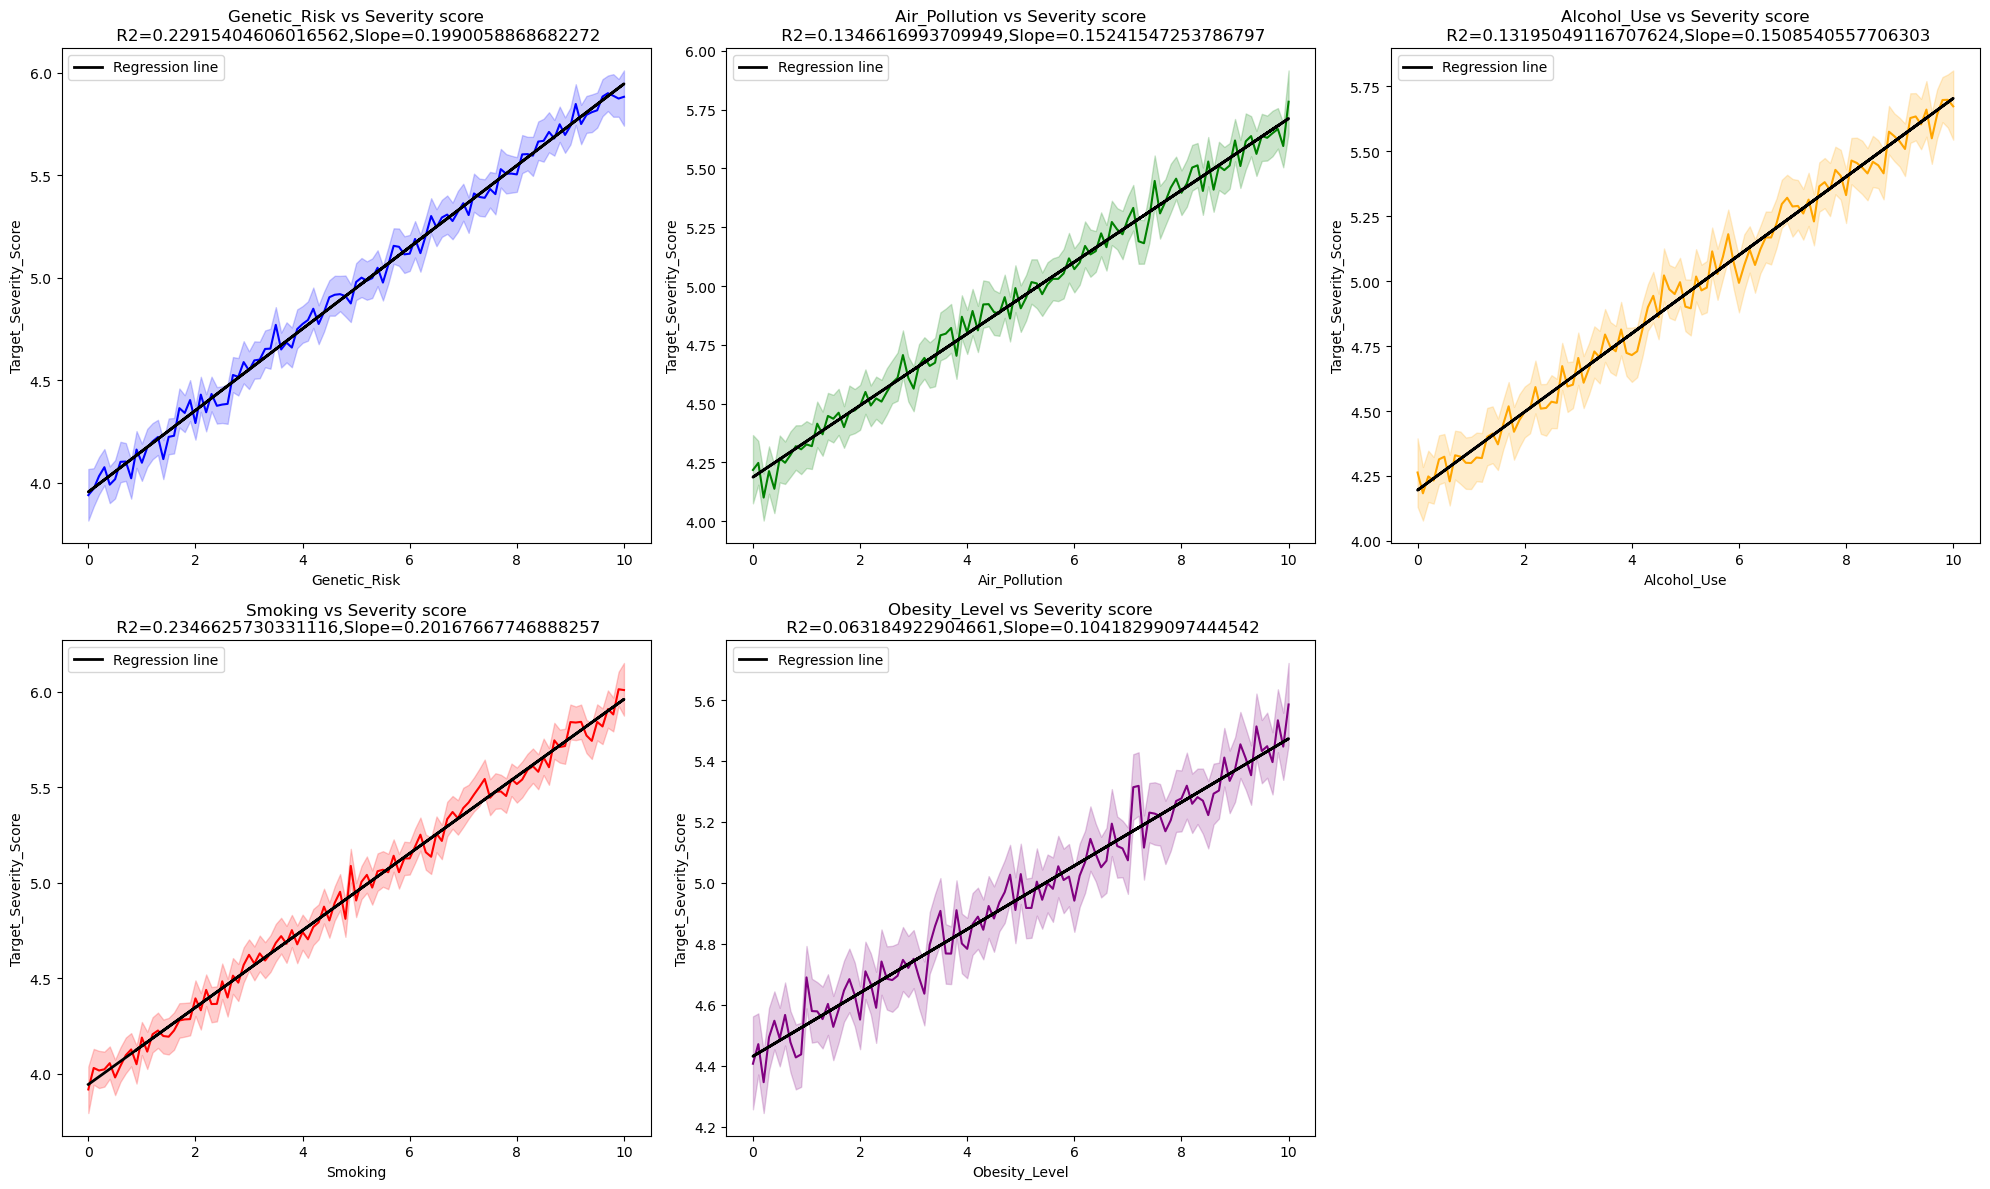

In [28]:
from scipy.stats import linregress
risk_factors=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
colors = ["blue","green","orange","red","purple"]

plt.figure(figsize=(20,12))
for i,(factor,title,color) in enumerate (zip(risk_factors,titles,colors),1):
    plt.subplot(2,3,i)
    x=data[factor]
    y=data["Target_Severity_Score"]
    slope,intercept,r_value,p_value,std_err=linregress(x,y)
    r_squared=r_value**2

    sns.lineplot(x=factor,y="Target_Severity_Score",data=data,color=color)
    plt.plot(x,x*slope+intercept, color="black",linewidth=2,label="Regression line")
    plt.title(f"{title} vs Severity score\n R2={r_squared},Slope={slope}")
    plt.xlabel(factor)
    plt.ylabel("Target_Severity_Score")
    plt.legend()

plt.tight_layout()
plt.show()

# Analyze the Propertion Of Early Stage diagnosis by cancer type

In [29]:
data["Cancer_Type"].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [33]:
stage_count=data[data["Cancer_Type"]=="Lung"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of lungs cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of lungs cancer diagnosed at stage 0 and stage 1:38.43156356551388


In [31]:
stage_count

Cancer_Stage
Stage II     1298
Stage IV     1286
Stage III    1208
Stage 0      1185
Stage I      1182
Name: count, dtype: int64

In [34]:
stage_count=data[data["Cancer_Type"]=="Leukemia"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Leukemia cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Leukemia cancer diagnosed at stage 0 and stage 1:39.53080114905841


In [35]:
stage_count=data[data["Cancer_Type"]=="Breast"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Breast cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Breast cancer diagnosed at stage 0 and stage 1:39.47325900791727


In [37]:
stage_count=data[data["Cancer_Type"]=="Skin"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Skin cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Skin cancer diagnosed at stage 0 and stage 1:40.41084898090194


In [38]:
stage_count=data[data["Cancer_Type"]=="Colon"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Colon cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Colon cancer diagnosed at stage 0 and stage 1:40.41718946047679


In [39]:
stage_count=data[data["Cancer_Type"]=="Cervical"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Cervical cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Cervical cancer diagnosed at stage 0 and stage 1:39.85856637737062


In [40]:
stage_count=data[data["Cancer_Type"]=="Prostate"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Prostate cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Prostate cancer diagnosed at stage 0 and stage 1:40.187064045656314


In [41]:
stage_count=data[data["Cancer_Type"]=="Liver"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Liver cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Liver cancer diagnosed at stage 0 and stage 1:40.614498319731155


# Identify key predictors of cancer severity and survival years

In [43]:
features = ["Age" ,'Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level' ]

targets=["Survival_Years","Target_Severity_Score"]

#calculate correlatins
pearson_corr = data[features+targets].corr(method="pearson")
spearman_corr = data[features+targets].corr(method="spearman")

#slice out only thr relationship with target variables
pearson_results = pearson_corr[targets]
spearman_results=spearman_corr[targets]

#combines both
correlation_df=pd.concat([pearson_results,spearman_results],axis=1,keys=["Pearson","Spearman"])
correlation_df

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000